# Solid State Project

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from turtle import color

## Simple 1D Tight Bing

### Task 1: Hamiltonian Construction

$$
H = -t \sum_n (\ket{n + 1}\bra{n} + \ket{n}\bra{n + 1})
$$

+ Write a program that constructs the Hamiltonian matrix in the periodic boundary condi1ons (PBC), where site $N$ is iden1fied with site $0$.

+ Modify the code to handle open boundary condi1ons (OBC), where sites $0$ and $N − 1$ are not connected.

In [36]:
# PBC 
def pbc_Hamiltonian(n, t = 1):
    H = np.zeros((n, n))
    for i in range(n):
        H[i, (i + 1) % n] = -t
        H[(i + 1) % n, i] = -t
    return H

# OBC
def obc_Hamiltonian(n, t = 1):
    H = np.zeros((n, n))
    for i in range(n - 1):
        H[i, i + 1] = -t
        H[i + 1, i] = -t
    return H

In [37]:
# Example
N = 5
H_PBC = pbc_Hamiltonian(N)
H_OBC = obc_Hamiltonian(N)

print("Hamiltonian in PBC:")
print(H_PBC)
print(scipy.linalg.ishermitian(H_PBC))
print("Hamiltonian in OBC:")
print(H_OBC)
print(scipy.linalg.ishermitian(H_OBC))

Hamiltonian in PBC:
[[ 0. -1.  0.  0. -1.]
 [-1.  0. -1.  0.  0.]
 [ 0. -1.  0. -1.  0.]
 [ 0.  0. -1.  0. -1.]
 [-1.  0.  0. -1.  0.]]
True
Hamiltonian in OBC:
[[ 0. -1.  0.  0.  0.]
 [-1.  0. -1.  0.  0.]
 [ 0. -1.  0. -1.  0.]
 [ 0.  0. -1.  0. -1.]
 [ 0.  0.  0. -1.  0.]]
True


### Task 2: Eigenvalue problem

+ Diagonalize your Hamiltonian for both boundary condi1ons for $N = 100$. It is convenient to use `numpy.linalg.eigh()`.

+  Plot the energy spectrum of both the periodic and open systems on the same figure. 
   +  How similar or different are they? 
   +  Is there a degeneracy in the periodic spectrum? 
   +  What is the origin of this degeneracy? 
   +  Does the open system break or preserve this degeneracy? Why? 

+  Plot the wave func1on probability distribu1on, $|\psi_m(x)|^2$, for the ground state and first two excited states of the **periodic** system as a func1on of posi1on and show them on the same plot. What do you notice about the first two excited states?

+ Plot the wave func1on probability distribu1on, $|\psi_m(x)|^2$, for the ground state and first
two excited states of the **open** system as a func1on of posi1on and show them on the
same plot. What do you notice about the number of nodes?

In [38]:
# Diagonalize
N = 100
E_PBC, psi_PBC = np.linalg.eigh(pbc_Hamiltonian(N))
E_OBC, psi_OBC = np.linalg.eigh(obc_Hamiltonian(N))

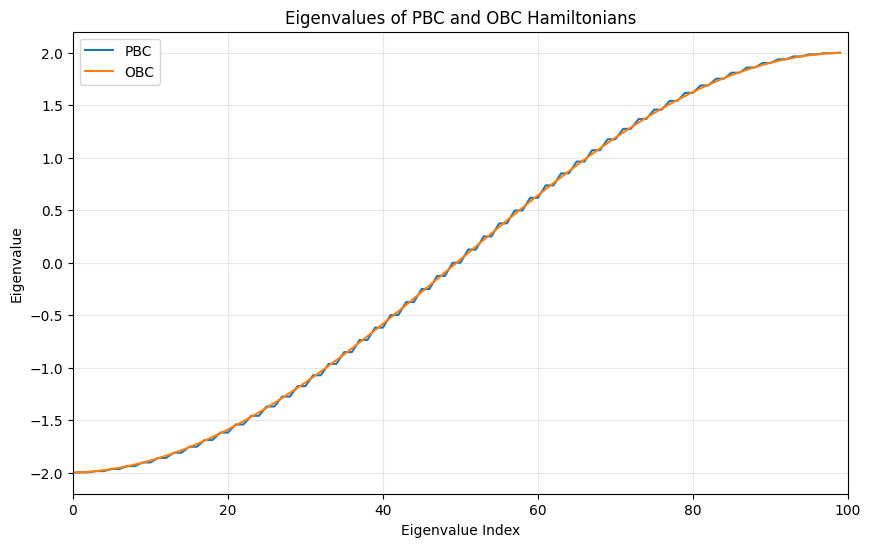

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(range(N), E_PBC, label='PBC')
plt.plot(range(N), E_OBC, label='OBC')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of PBC and OBC Hamiltonians')
plt.legend(loc='upper left')
plt.grid(True, alpha = 0.3)
plt.xlim(0, N)
plt.show()

1. They are alike. For each point, the periodic and open spectra have almost the same energy.
2. Yes, there's a degeneracy. 
3. The degeneracy comes from translational symmetry in the periodic system. With PBC, the eigenstates can be labeled by momentum k, and the energy is E(k) = -2t cos(k). Since cos(k) = cos(-k), the +k and -k states have the same energy.
4. Open boundaries destroy translational symmetry because the first and last sites are no longer connected, so not every site has the same environment. The eigenstates become standing waves instead of traveling momentum states, so the +k/-k degeneracy is broken.

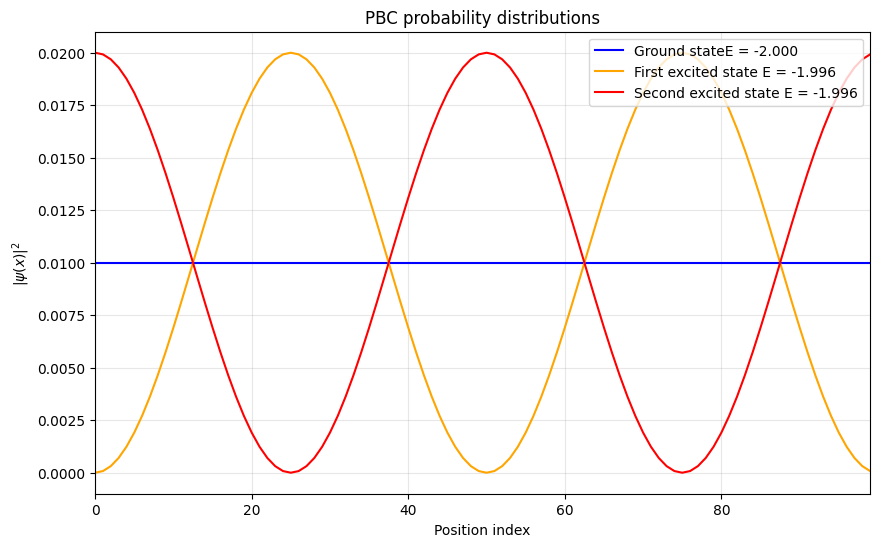

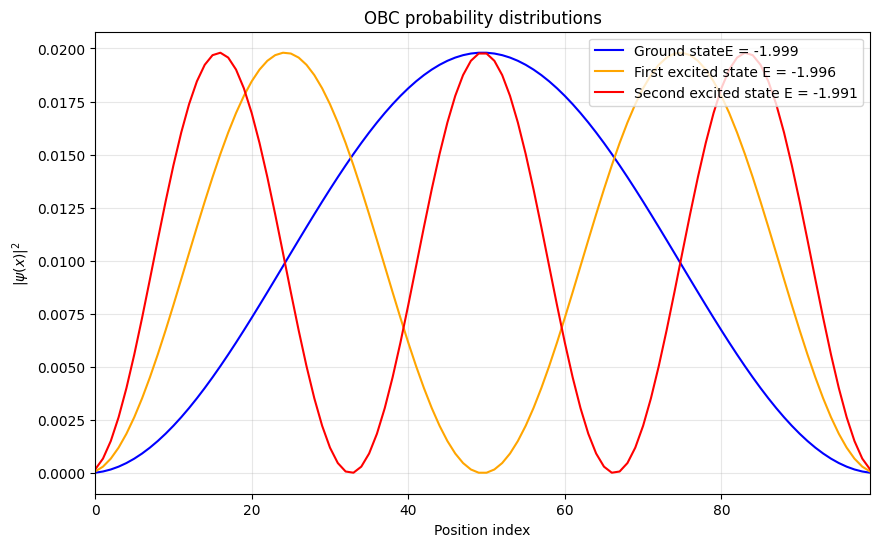

In [40]:
# Ground state and first two excited state probability plots

def plot_ground_and_excited_states(N, E, psi, title):
    x = np.arange(N)

    psi_gs = psi[:, 0]   # ground state
    psi_e1 = psi[:, 1]   # first excited state
    psi_e2 = psi[:, 2]   # second excited state

    plt.figure(figsize=(10, 6))
    plt.plot(x, np.abs(psi_gs)**2, label=f"{'Ground state':}E = {E[0]:.3f}", color="blue")
    plt.plot(x, np.abs(psi_e1)**2, label=f"{'First excited state':} E = {E[1]:.3f}", color="orange")
    plt.plot(x, np.abs(psi_e2)**2, label=f"{'Second excited state':} E = {E[2]:.3f}", color="red")

    plt.xlabel("Position index")
    plt.ylabel(r"$|\psi(x)|^2$")
    plt.xlim(0, N-1)
    plt.title(title)
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_ground_and_excited_states(N, E_PBC, psi_PBC, "PBC probability distributions")
plot_ground_and_excited_states(N, E_OBC, psi_OBC, "OBC probability distributions")


1. They have the same energy, but have eigenstates with a overall phase of $\pi$
2. 1, 3, 5

## SSH Model

### Task 1: Hamiltonian constructon

$$
H = - \sum_{n = 0} (\nu \ket{n; B}\bra{n; A} + \omega \ket{n+1; A}\bra{n; B} + \text{h.c.})
$$

+ Write a program to construct the Hamiltonian matrix for this system in both periodic and open boundary condi1ons. Make sure that there is an equal number of $A$ and $B$ sites.

In [41]:
# PBC 
def pbc_Hamiltonian(n, nu, omega = 1):
    H = np.zeros((2 * n, 2 * n))
    for i in range(n):
        H[2 * i + 1, 2 * i] = -nu
        H[2 * i, 2 * i + 1] = -nu
        H[2 * (i + 1) % (2 * n), 2 * i + 1] = -omega
        H[2 * i + 1, 2 * (i + 1) % (2 * n)] = -omega
    return H

# OBC
def obc_Hamiltonian(n, nu, omega=1):
    H = np.zeros((2 * n, 2 * n))
    for i in range(n):
        H[2 * i + 1, 2 * i] = -nu
        H[2 * i, 2 * i + 1] = -nu
    for i in range(n - 1):
        H[2 * (i + 1), 2 * i + 1] = -omega
        H[2 * i + 1, 2 * (i + 1)] = -omega

    return H

In [42]:
# Example
N = 5
nu = 2
omega = 1
H_PBC = pbc_Hamiltonian(N, nu, omega)
H_OBC = obc_Hamiltonian(N, nu, omega)

print("Hamiltonian in PBC:")
print(H_PBC)
print(scipy.linalg.ishermitian(H_PBC))
print("Hamiltonian in OBC:")
print(H_OBC)
print(scipy.linalg.ishermitian(H_OBC))

Hamiltonian in PBC:
[[ 0. -2.  0.  0.  0.  0.  0.  0.  0. -1.]
 [-2.  0. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0. -2.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -2.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0. -2.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -2.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0. -2.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -2.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  0. -2.]
 [-1.  0.  0.  0.  0.  0.  0.  0. -2.  0.]]
True
Hamiltonian in OBC:
[[ 0. -2.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-2.  0. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0. -2.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -2.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0. -2.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -2.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0. -2.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -2.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  0. -2.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -2.  0.]]
True


### Task 2: Bulk band structure

+ Numerically calculate the band structure for the periodic system for $N = 100$ for different ra1os of $\nu/\omega = \{0.5,1,2\}$. Which parameters correspond to a metal and which correspond to an insulator?
+ Plot the numerical band structures for the different parameters of $\nu/\omega$.

In [51]:
# Diagonalize
N = 100
nu_1 = 0.5
nu_2 = 1
nu_3 = 2
omega = 1
E_PBC_1, psi_PBC_1 = np.linalg.eigh(pbc_Hamiltonian(N, nu_1, omega))
E_PBC_2, psi_PBC_2 = np.linalg.eigh(pbc_Hamiltonian(N, nu_2, omega))
E_PBC_3, psi_PBC_3 = np.linalg.eigh(pbc_Hamiltonian(N, nu_3, omega))

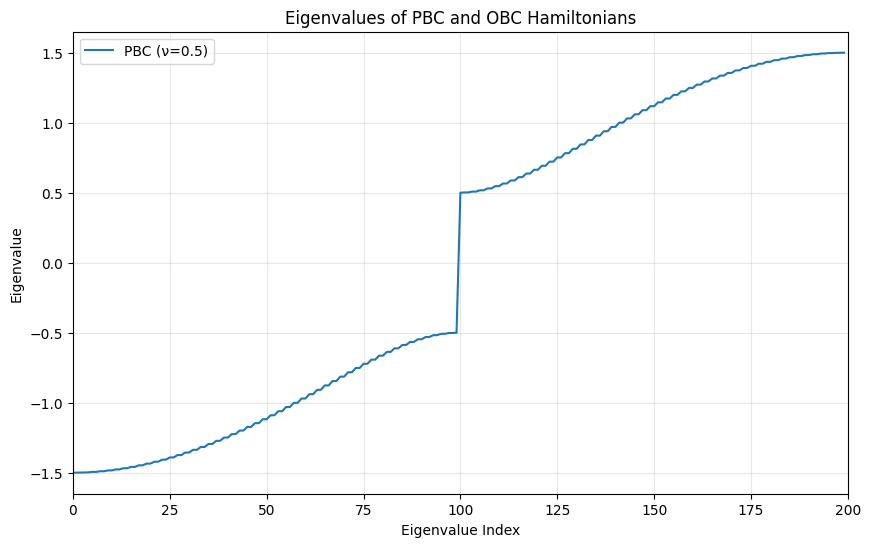

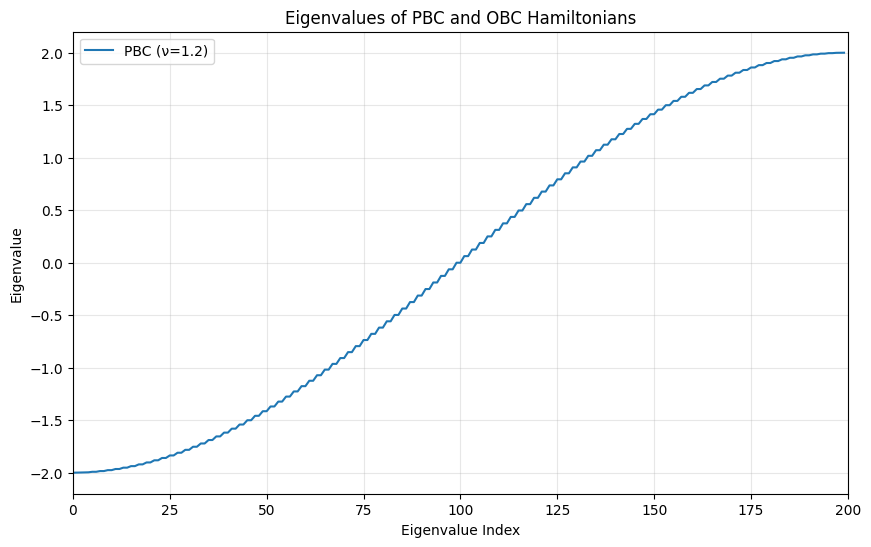

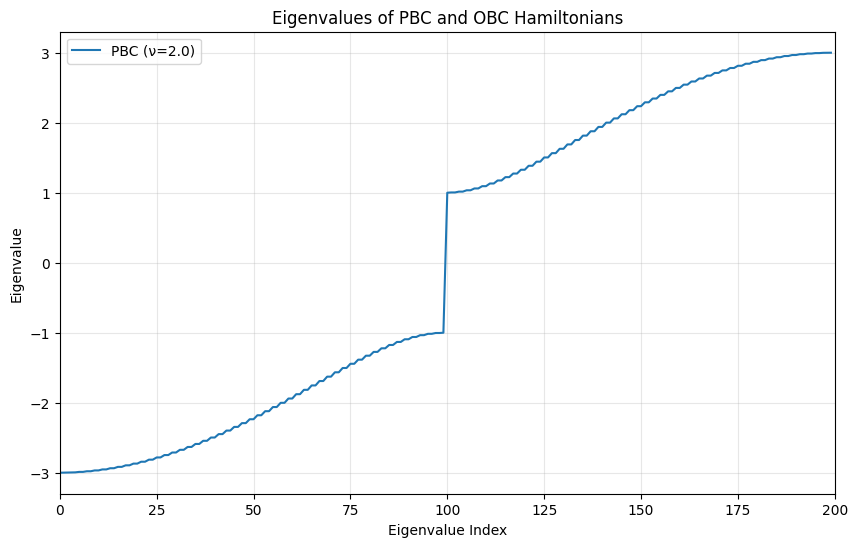

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(range(2 * N), E_PBC_1, label='PBC (ν=0.5)')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of PBC and OBC Hamiltonians')
plt.legend(loc='upper left')
plt.grid(True, alpha = 0.3)
plt.xlim(0, 2 * N)
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(range(2 * N), E_PBC_2, label='PBC (ν=1.2)')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of PBC and OBC Hamiltonians')
plt.legend(loc='upper left')
plt.grid(True, alpha = 0.3)
plt.xlim(0, 2 * N)
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(range(2 * N), E_PBC_3, label='PBC (ν=2.0)')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of PBC and OBC Hamiltonians')
plt.legend(loc='upper left')
plt.grid(True, alpha = 0.3)
plt.xlim(0, 2 * N)
plt.show()

+ $\nu = 1$ metal
+ $\nu = 0.5, 2$, insulator

## Task 3: Edge States

+ Construct the OBC Hamiltonian of the SSH model for 𝑁 = 50 and plot the energy spectrum for different ra1os of $\nu/\omega = \{0.5,1,2\}$.
+ Iden1fy the zero-energy states for the case when $\nu/\omega$. How many are they?
+ Plot the zero-energy states wavefunc1ons and verify that they are localized at the boundaries, hence the name ‘edge’ states.